Q1. Statistical Mechanics of the Quantum Oscillator

Maximum verification error for U = F + TS:
4.513898307157584e-36


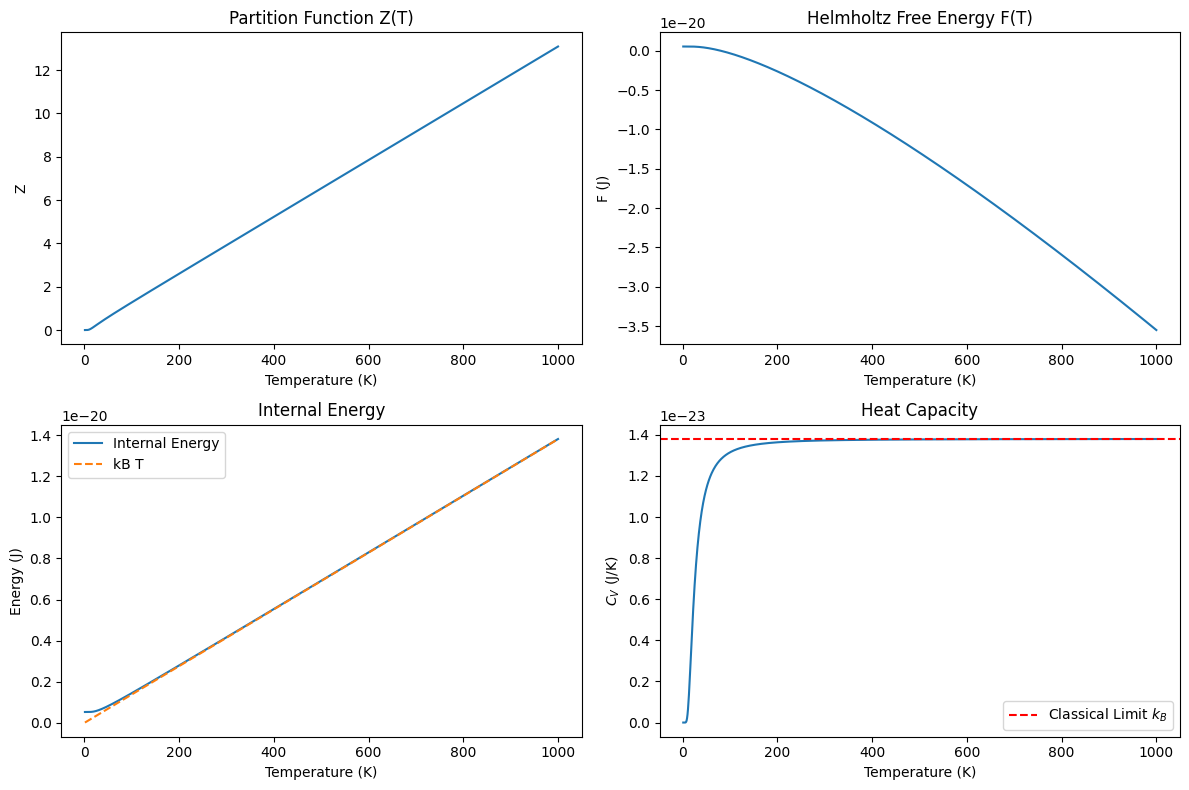


High-temperature heat capacity:
Cv(T_max) = 1.379977940367924e-23 J/K
kB        = 1.380649e-23 J/K
Cv/kB     = 0.999513953487037


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Physical Constants (SI)
# -------------------------
hbar = 1.054571817e-34      # J·s
kB   = 1.380649e-23         # J/K

# Example oscillator frequency
omega = 1e13                # rad/s

# Temperature range
T = np.linspace(1, 1000, 1000)

# -------------------------
# Partition Function
# Z = exp(-ħω/2kBT)/(1-exp(-ħω/kBT))
# -------------------------
x = hbar * omega / (kB * T)

Z = np.exp(-x/2) / (1 - np.exp(-x))

# -------------------------
# Helmholtz Free Energy
# F = -kBT ln(Z)
# -------------------------
F = -kB * T * np.log(Z)

# -------------------------
# Internal Energy
# U = ħω/2 + ħω/(exp(ħω/kBT)-1)
# -------------------------
U = hbar*omega/2 + hbar*omega/(np.exp(x)-1)

# -------------------------
# Entropy
# S = (U - F)/T
# -------------------------
S = (U - F)/T

# -------------------------
# Heat Capacity
#
# Cv = kB (ħω/2kBT)^2 / sinh²(ħω/2kBT)
# -------------------------
Cv = kB * (x/2)**2 / (np.sinh(x/2)**2)

# -------------------------
# Verify Thermodynamic Identity
# U = F + T*S
# -------------------------
error = np.max(np.abs(U - (F + T*S)))

print("Maximum verification error for U = F + TS:")
print(error)

# -------------------------
# Plots
# -------------------------
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0,0].plot(T, Z)
ax[0,0].set_title("Partition Function Z(T)")
ax[0,0].set_xlabel("Temperature (K)")
ax[0,0].set_ylabel("Z")

ax[0,1].plot(T, F)
ax[0,1].set_title("Helmholtz Free Energy F(T)")
ax[0,1].set_xlabel("Temperature (K)")
ax[0,1].set_ylabel("F (J)")

ax[1,0].plot(T, U, label='Internal Energy')
ax[1,0].plot(T, kB*T, '--', label='kB T')
ax[1,0].set_title("Internal Energy")
ax[1,0].set_xlabel("Temperature (K)")
ax[1,0].set_ylabel("Energy (J)")
ax[1,0].legend()

ax[1,1].plot(T, Cv)
ax[1,1].axhline(kB, color='r', linestyle='--',
                label='Classical Limit $k_B$')
ax[1,1].set_title("Heat Capacity")
ax[1,1].set_xlabel("Temperature (K)")
ax[1,1].set_ylabel("$C_V$ (J/K)")
ax[1,1].legend()

plt.tight_layout()
plt.show()

# -------------------------
# High-temperature limit
# -------------------------
print("\nHigh-temperature heat capacity:")
print("Cv(T_max) =", Cv[-1], "J/K")
print("kB        =", kB, "J/K")
print("Cv/kB     =", Cv[-1]/kB)

Q2. The Maximum Entropy Distribution under Mean and Variance Constraints

Normalization = 1.0
Mean          = 0.0
Variance      = 4.000000000000001

Differential Entropy
Numerical = nan
Theory    = 2.112085713764618


/tmp/ipykernel_673/761561112.py:68: RuntimeWarning: divide by zero encountered in log
  lambda x: -p(x) * np.log(p(x)),
/tmp/ipykernel_673/761561112.py:68: RuntimeWarning: invalid value encountered in scalar multiply
  lambda x: -p(x) * np.log(p(x)),
/tmp/ipykernel_673/761561112.py:67: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  entropy_num, _ = quad(


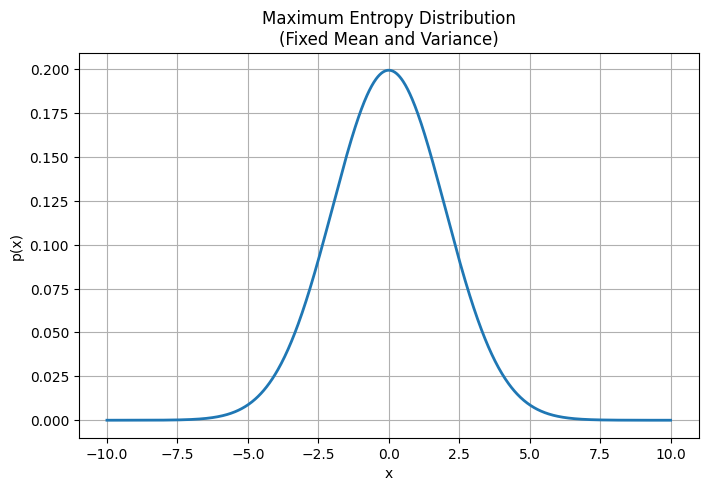

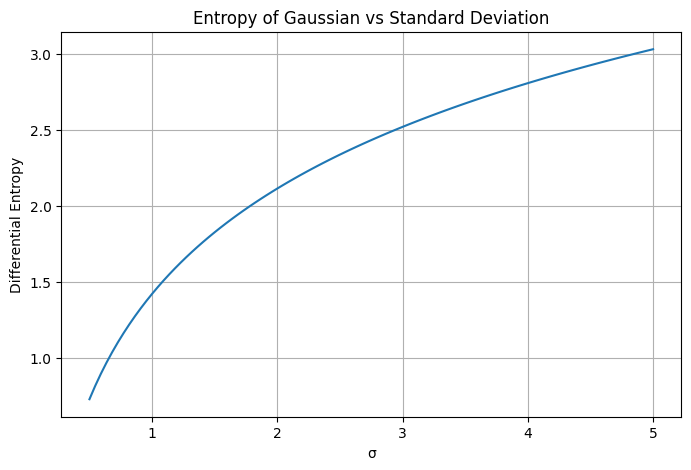

In [2]:
# ==========================================================
# Maximum Entropy Distribution with Fixed Mean and Variance
# Result: Gaussian Distribution
#
# Constraints:
# E[X] = μ
# Var(X) = σ²
#
# This notebook:
# 1. Defines the maximum-entropy Gaussian
# 2. Numerically verifies normalization
# 3. Verifies mean = μ
# 4. Verifies variance = σ²
# 5. Computes differential entropy
# 6. Plots the distribution
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# -------------------------
# Parameters
# -------------------------
mu = 0.0
sigma = 2.0

# -------------------------
# Maximum Entropy PDF
# Gaussian Distribution
# -------------------------
def p(x):
    return (1 / np.sqrt(2 * np.pi * sigma**2)) * np.exp(
        -(x - mu)**2 / (2 * sigma**2)
    )

# -------------------------
# Verify normalization
# ∫ p(x) dx = 1
# -------------------------
norm, _ = quad(p, -np.inf, np.inf)

# -------------------------
# Verify mean
# E[X]
# -------------------------
mean, _ = quad(lambda x: x * p(x), -np.inf, np.inf)

# -------------------------
# Verify variance
# E[(X-μ)^2]
# -------------------------
variance, _ = quad(
    lambda x: (x - mu)**2 * p(x),
    -np.inf,
    np.inf
)

# -------------------------
# Differential Entropy
#
# h(X) = -∫ p(x) ln p(x) dx
#
# For Gaussian:
# h = 1/2 ln(2πeσ²)
# -------------------------
entropy_num, _ = quad(
    lambda x: -p(x) * np.log(p(x)),
    -np.inf,
    np.inf
)

entropy_theory = 0.5 * np.log(
    2 * np.pi * np.e * sigma**2
)

# -------------------------
# Print Results
# -------------------------
print("Normalization =", norm)
print("Mean          =", mean)
print("Variance      =", variance)

print("\nDifferential Entropy")
print("Numerical =", entropy_num)
print("Theory    =", entropy_theory)

# -------------------------
# Plot PDF
# -------------------------
x = np.linspace(
    mu - 5*sigma,
    mu + 5*sigma,
    1000
)

plt.figure(figsize=(8,5))
plt.plot(x, p(x), lw=2)

plt.title(
    "Maximum Entropy Distribution\n"
    "(Fixed Mean and Variance)"
)

plt.xlabel("x")
plt.ylabel("p(x)")
plt.grid(True)

plt.show()

# -------------------------
# Compare Entropy for
# Different Variances
# -------------------------
sigmas = np.linspace(0.5, 5, 100)

entropies = 0.5 * np.log(
    2 * np.pi * np.e * sigmas**2
)

plt.figure(figsize=(8,5))
plt.plot(sigmas, entropies)

plt.title("Entropy of Gaussian vs Standard Deviation")
plt.xlabel("σ")
plt.ylabel("Differential Entropy")
plt.grid(True)

plt.show()

Q3. Multiclass Logistic Regression: Automatic Classification of Emails

In [3]:
# =====================================================
# Maximum Entropy Email Routing Example
# =====================================================

import numpy as np
from scipy.optimize import fsolve

# -----------------------------------------------------
# Feature states and probabilities
# -----------------------------------------------------

states = {
    "A": np.array([1,0,0]),
    "B": np.array([0,1,0]),
    "C": np.array([0,0,1]),
    "D": np.array([0,1,1]),
    "E": np.array([1,1,0])
}

P_x = {
    "A": 0.40,
    "B": 0.25,
    "C": 0.15,
    "D": 0.15,
    "E": 0.05
}

# -----------------------------------------------------
# Constraint values
# -----------------------------------------------------

target1 = 0.05
target2 = 0.15
target3 = 0.16

# -----------------------------------------------------
# Logistic probability
# P(Y=1|x)
# -----------------------------------------------------

def sigmoid(z):
    return 1/(1+np.exp(-z))

def p_y1(x, lamb):
    return sigmoid(np.dot(lamb, x))

# -----------------------------------------------------
# Constraint equations
# -----------------------------------------------------

def equations(lamb):

    c1 = 0
    c2 = 0
    c3 = 0

    for key, x in states.items():

        prob = p_y1(x, lamb)

        c1 += P_x[key] * x[0] * prob
        c2 += P_x[key] * x[1] * prob
        c3 += P_x[key] * x[2] * prob

    return [
        c1 - target1,
        c2 - target2,
        c3 - target3
    ]

# -----------------------------------------------------
# Solve for λ
# -----------------------------------------------------

initial_guess = [-2, 0, 2]

solution = fsolve(equations, initial_guess)

print("Maximum Entropy Parameters")
print("--------------------------")
print("lambda1 =", solution[0])
print("lambda2 =", solution[1])
print("lambda3 =", solution[2])

# -----------------------------------------------------
# Probabilities for each scenario
# -----------------------------------------------------

print("\nP(Y=1 | x)")
print("--------------------------")

for key, x in states.items():

    p = p_y1(x, solution)

    print(
        f"Scenario {key}: "
        f"x={x} --> "
        f"P(Y=1|x)={p:.4f}"
    )

# -----------------------------------------------------
# Verify constraints
# -----------------------------------------------------

c1 = c2 = c3 = 0

for key, x in states.items():

    p = p_y1(x, solution)

    c1 += P_x[key] * x[0] * p
    c2 += P_x[key] * x[1] * p
    c3 += P_x[key] * x[2] * p

print("\nConstraint Verification")
print("--------------------------")
print("E[x1 I(Y=1)] =", c1)
print("Target       =", target1)

print("\nE[x2 I(Y=1)] =", c2)
print("Target       =", target2)

print("\nE[x3 I(Y=1)] =", c3)
print("Target       =", target3)

# -----------------------------------------------------
# Visualize probabilities
# -----------------------------------------------------



Maximum Entropy Parameters
--------------------------
lambda1 = -2.0159468731689723
lambda2 = -0.7410973291161703
lambda3 = 0.5087088133537224

P(Y=1 | x)
--------------------------
Scenario A: x=[1 0 0] --> P(Y=1|x)=0.1175
Scenario B: x=[0 1 0] --> P(Y=1|x)=0.3228
Scenario C: x=[0 0 1] --> P(Y=1|x)=0.6245
Scenario D: x=[0 1 1] --> P(Y=1|x)=0.4422
Scenario E: x=[1 1 0] --> P(Y=1|x)=0.0597

Constraint Verification
--------------------------
E[x1 I(Y=1)] = 0.04999999999999247
Target       = 0.05

E[x2 I(Y=1)] = 0.14999999999999122
Target       = 0.15

E[x3 I(Y=1)] = 0.15999999999999476
Target       = 0.16


Q4. Asset Pricing and Portfolio Optimization.

In [6]:
# ==========================================================
# Maximum Entropy Portfolio Problem
#
# Constraints:
# E[S]      = 102
# E[S²]     = 10600
# E[ln(S)]  = 4.60
#
# p(S) ∝ exp(-λ1 S - λ2 S² - λ3 ln(S))
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import quad
from scipy.optimize import fsolve

# ----------------------------------------------------------
# Target constraints
# ----------------------------------------------------------

TARGET_MEAN = 102.0
TARGET_SECOND = 10600.0
TARGET_LOG = 4.60

# ----------------------------------------------------------
# Unnormalized density
# ----------------------------------------------------------

def q(s, l1, l2, l3):
    return np.exp(
        -l1*s
        -l2*s**2
        -l3*np.log(s)
    )

# ----------------------------------------------------------
# Partition function
# ----------------------------------------------------------

def Z(l1, l2, l3):

    val, _ = quad(
        lambda s: q(s,l1,l2,l3),
        1e-6,
        np.inf,
        limit=500
    )

    return val

# ----------------------------------------------------------
# Expectations
# ----------------------------------------------------------

def expectation(func, l1, l2, l3):

    z = Z(l1,l2,l3)

    num, _ = quad(
        lambda s: func(s)*q(s,l1,l2,l3),
        1e-6,
        np.inf,
        limit=500
    )

    return num/z

# ----------------------------------------------------------
# System of equations
# ----------------------------------------------------------

def equations(params):

    l1,l2,l3 = params

    m1 = expectation(lambda s: s, l1,l2,l3)

